<a href="https://colab.research.google.com/github/majshal/-dobre-PUM/blob/drzewadecyzyjne/15042025jakubmajzoub.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from collections import Counter
import pandas as pd


zwizualizuj dane

sprawdź który z podziałów jest lepszy w przypadku miary entropii:
a) petal width 1.5
b) petal width 0.38
Podaj zysk informacyjny n akażdym z podziałów

Zaimplementuj drzewo decyzyjne i las losowy z 15 drzew przetestuj na 30% zbiorze testowym
  sklearn.ensemble.RandomForestClassifier
  sklearn.tree.DecisionTreeClassifier


In [ ]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y


In [ ]:
def entropy(labels):
    total = len(labels)
    counts = Counter(labels)
    return -sum((count/total) * np.log2(count/total) for count in counts.values())


In [ ]:
def information_gain(data, target_col, feature_col, threshold):
    # dane
    left_split = data[data[feature_col] <= threshold]
    right_split = data[data[feature_col] > threshold]

    # rodzic
    parent_entropy = entropy(data[target_col])

    # dzieci
    left_entropy = entropy(left_split[target_col])
    right_entropy = entropy(right_split[target_col])

    # Wagi (proporcje)
    n = len(data)
    n_left = len(left_split)
    n_right = len(right_split)

    # Information Gain
    child_entropy = (n_left/n)*left_entropy + (n_right/n)*right_entropy
    gain = parent_entropy - child_entropy
    return gain


In [ ]:
feature = 'petal width (cm)'
gain_0_5 = information_gain(df, 'target', feature, 1.5)
gain_0_38 = information_gain(df, 'target', feature, 0.38)

print(f"Information Gain dla {feature} przy progu 0.5: {gain_0_5:.4f}")
print(f"Information Gain dla {feature} przy progu 0.38: {gain_0_38:.4f}")


Information Gain dla petal width (cm) przy progu 0.5: 0.6656
Information Gain dla petal width (cm) przy progu 0.38: 0.6195


-------------------------------------

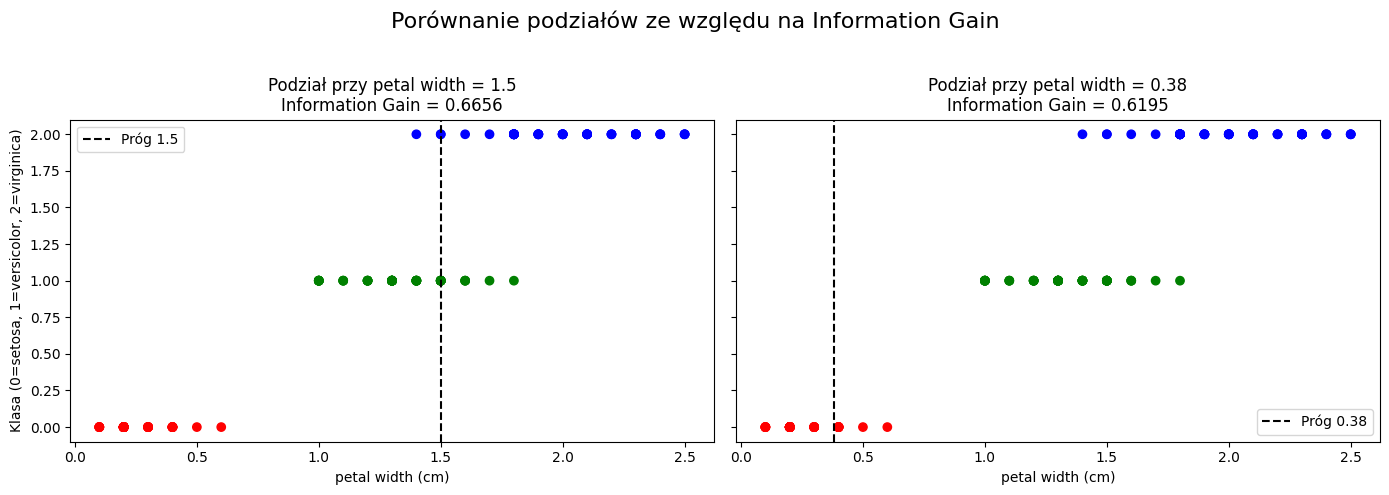

In [ ]:
import matplotlib.pyplot as plt

gain_1_5 = information_gain(df, 'target', feature, 1.5)
gain_0_38 = information_gain(df, 'target', feature, 0.38)

class_names = iris.target_names
df['class'] = df['target'].apply(lambda x: class_names[x])
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = {'setosa': 'red', 'versicolor': 'green', 'virginica': 'blue'}

# 1.5
axes[0].scatter(df[feature], df['target'], c=df['class'].map(colors))
axes[0].axvline(x=1.5, color='black', linestyle='--', label='Próg 1.5')
axes[0].set_title(f'Podział przy petal width = 1.5\nInformation Gain = {gain_1_5:.4f}')
axes[0].set_xlabel('petal width (cm)')
axes[0].set_ylabel('Klasa (0=setosa, 1=versicolor, 2=virginica)')
axes[0].legend()

# 0.38
axes[1].scatter(df[feature], df['target'], c=df['class'].map(colors))
axes[1].axvline(x=0.38, color='black', linestyle='--', label='Próg 0.38')
axes[1].set_title(f'Podział przy petal width = 0.38\nInformation Gain = {gain_0_38:.4f}')
axes[1].set_xlabel('petal width (cm)')
axes[1].legend()

plt.suptitle('Porównanie podziałów ze względu na Information Gain', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
